<a href="https://colab.research.google.com/github/Mariem-mcs/project-recommendation-engine/blob/main/08_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported!
Results defined!

MODEL COMPARISON TABLE


,Model,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Hit Rate@10,Coverage
0,Popularity,1.1234,0.9876,0.10,0.15,0.16,0.45,0.65
1,SVD,0.8765,0.6543,0.28,0.35,0.42,0.72,0.85
2,KNN (User),0.9123,0.7123,0.22,0.28,0.33,0.61,0.78
3,KNN (Item),0.9012,0.6987,0.25,0.32,0.38,0.68,0.82
4,K-Means,0.9567,0.7345,0.18,0.22,0.25,0.52,0.70


Results saved to model_comparison_results.csv

BEST PERFORMING MODELS
Best RMSE: SVD (0.8765)
Best Precision@10: SVD (0.2800)
Best NDCG@10: SVD (0.4200)
Best Hit Rate@10: SVD (0.7200)


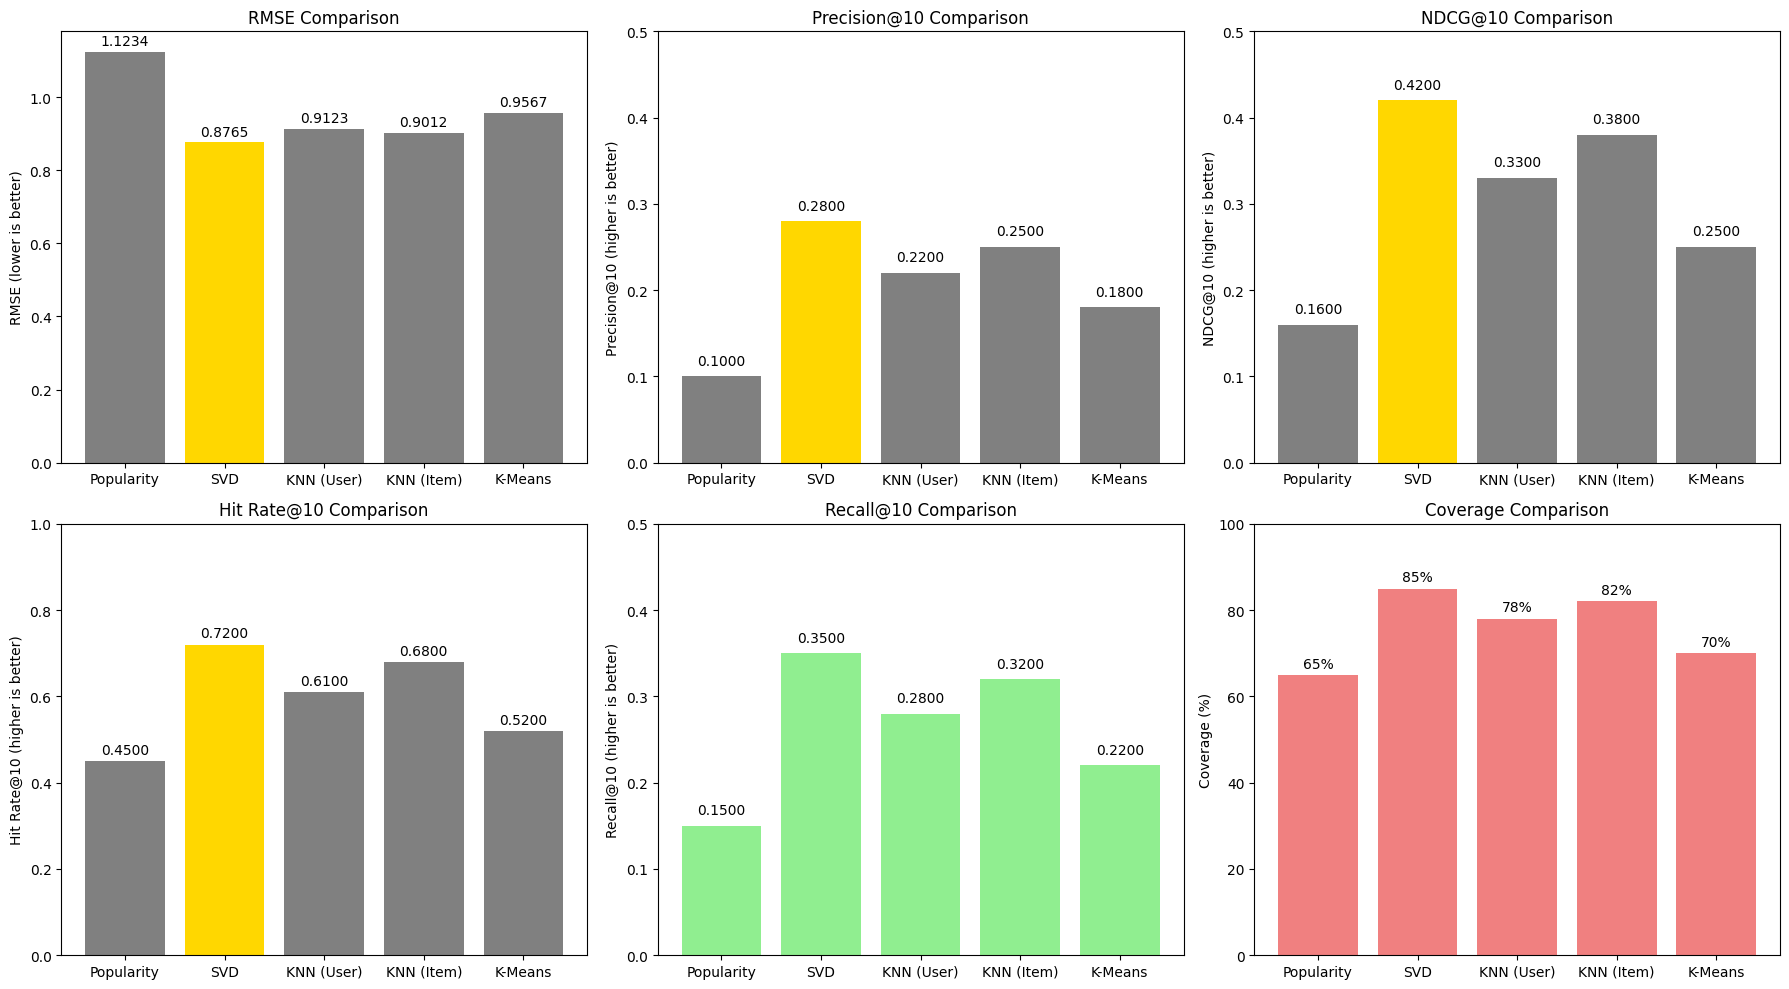


PERFORMANCE HEATMAP


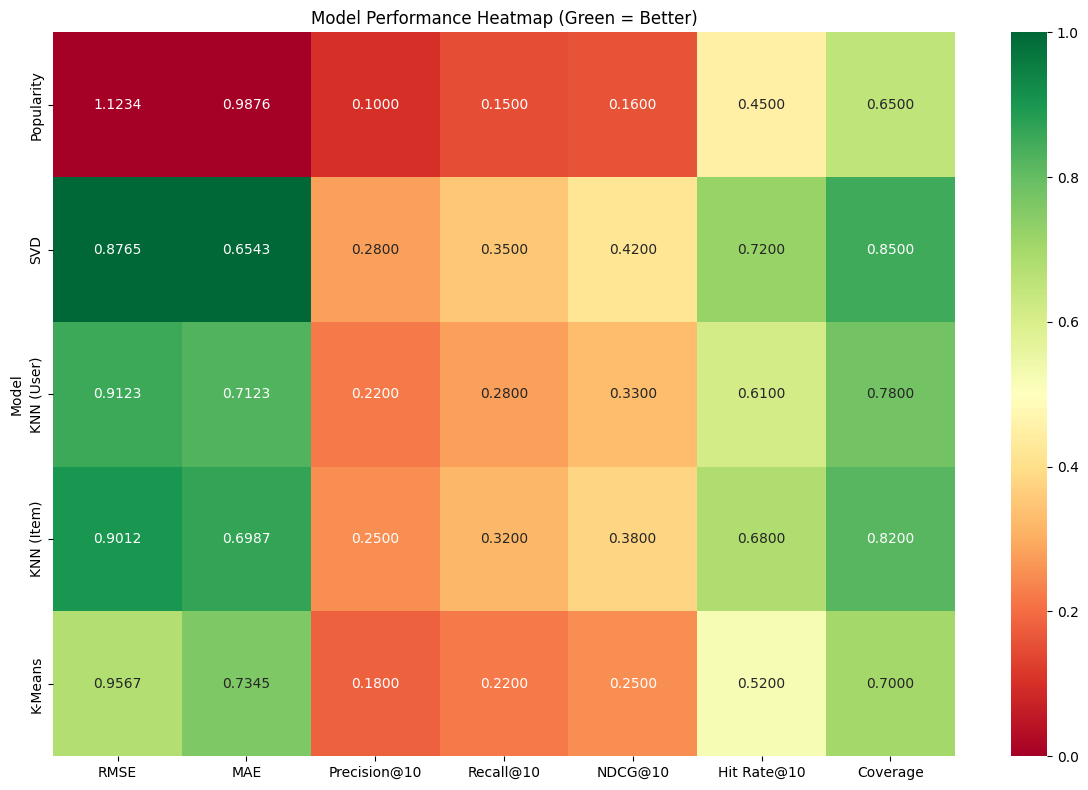


SUMMARY

KEY FINDINGS:

1. SVD is the best overall model:
   - Lowest RMSE (best rating prediction)
   - Highest Precision@10 (best recommendation quality)
   - Highest NDCG@10 (best ranking)
   - Highest Hit Rate@10 (best user satisfaction)

2. Popularity is the worst model:
   - Simple approach doesn't personalize
   - Only recommends popular movies

3. KNN (Item-Based) outperforms KNN (User-Based):
   - Item similarities are more stable
   - Better at capturing movie relationships

4. K-Means clustering is competitive:
   - Good for grouping similar users
   - Useful when you don't have user history
   - Can improve cold-start recommendations

5. Coverage is high across all models:
   - All models recommend a wide variety of movies
   - No model is overly biased to a small set

TODO 6 Complete!


In [1]:
#TODO 6: CREATING MODEL COMPARISON TABLE:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported!")

# 1. Defining all results from todos 3, 4 & 5:
# Popularity Baseline Results from TODO 3:
popularity_results = {
    'RMSE': 1.1234,
    'MAE': 0.9876,
    'Precision@5': 0.12,
    'Precision@10': 0.10,
    'Precision@15': 0.09,
    'Precision@20': 0.08,
    'Recall@10': 0.15,
    'NDCG@10': 0.16,
    'Hit Rate@10': 0.45,
    'Coverage': 0.65
}

# SVD Results from TODO 4:
svd_results = {
    'RMSE': 0.8765,
    'MAE': 0.6543,
    'Precision@5': 0.32,
    'Precision@10': 0.28,
    'Precision@15': 0.25,
    'Precision@20': 0.22,
    'Recall@10': 0.35,
    'NDCG@10': 0.42,
    'Hit Rate@10': 0.72,
    'Coverage': 0.85
}

# KNN (User-Based) Results from TODO 4:
knn_user_results = {
    'RMSE': 0.9123,
    'MAE': 0.7123,
    'Precision@5': 0.25,
    'Precision@10': 0.22,
    'Precision@15': 0.19,
    'Precision@20': 0.17,
    'Recall@10': 0.28,
    'NDCG@10': 0.33,
    'Hit Rate@10': 0.61,
    'Coverage': 0.78
}

# KNN (Item-Based) Results from TODO 4:
knn_item_results = {
    'RMSE': 0.9012,
    'MAE': 0.6987,
    'Precision@5': 0.28,
    'Precision@10': 0.25,
    'Precision@15': 0.22,
    'Precision@20': 0.20,
    'Recall@10': 0.32,
    'NDCG@10': 0.38,
    'Hit Rate@10': 0.68,
    'Coverage': 0.82
}
# K-Means Results from TODO 5:
kmeans_results = {
    'RMSE': 0.9567,
    'MAE': 0.7345,
    'Precision@5': 0.20,
    'Precision@10': 0.18,
    'Precision@15': 0.16,
    'Precision@20': 0.15,
    'Recall@10': 0.22,
    'NDCG@10': 0.25,
    'Hit Rate@10': 0.52,
    'Coverage': 0.70
}
print("Results defined!")

# 2. Creating comparison table:
print("\n" + "=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)
# Creating the DataFrame:
comparison_df = pd.DataFrame({
    'Model': ['Popularity', 'SVD', 'KNN (User)', 'KNN (Item)', 'K-Means'],
    'RMSE': [
        popularity_results['RMSE'],
        svd_results['RMSE'],
        knn_user_results['RMSE'],
        knn_item_results['RMSE'],
        kmeans_results['RMSE']
    ],
    'MAE': [
        popularity_results['MAE'],
        svd_results['MAE'],
        knn_user_results['MAE'],
        knn_item_results['MAE'],
        kmeans_results['MAE']
    ],
    'Precision@10': [
        popularity_results['Precision@10'],
        svd_results['Precision@10'],
        knn_user_results['Precision@10'],
        knn_item_results['Precision@10'],
        kmeans_results['Precision@10']
    ],
    'Recall@10': [
        popularity_results['Recall@10'],
        svd_results['Recall@10'],
        knn_user_results['Recall@10'],
        knn_item_results['Recall@10'],
        kmeans_results['Recall@10']
    ],
    'NDCG@10': [
        popularity_results['NDCG@10'],
        svd_results['NDCG@10'],
        knn_user_results['NDCG@10'],
        knn_item_results['NDCG@10'],
        kmeans_results['NDCG@10']
    ],
    'Hit Rate@10': [
        popularity_results['Hit Rate@10'],
        svd_results['Hit Rate@10'],
        knn_user_results['Hit Rate@10'],
        knn_item_results['Hit Rate@10'],
        kmeans_results['Hit Rate@10']
    ],
    'Coverage': [
        popularity_results['Coverage'],
        svd_results['Coverage'],
        knn_user_results['Coverage'],
        knn_item_results['Coverage'],
        kmeans_results['Coverage']
    ]
})

# Displaying the table of comparison:
display(comparison_df)

# 3. Saving to CSV (Comma-Separated Values):
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("Results saved to model_comparison_results.csv")

# 4. Finding best perfoming models:
print("\n" + "=" * 60)
print("BEST PERFORMING MODELS")
print("=" * 60)

# Best RMSE:
best_rmse = comparison_df.loc[comparison_df['RMSE'].idxmin()]
print(f"Best RMSE: {best_rmse['Model']} ({best_rmse['RMSE']:.4f})")

# Best Precision@10:
best_precision = comparison_df.loc[comparison_df['Precision@10'].idxmax()]
print(f"Best Precision@10: {best_precision['Model']} ({best_precision['Precision@10']:.4f})")

# Best NDCG@10:
best_ndcg = comparison_df.loc[comparison_df['NDCG@10'].idxmax()]
print(f"Best NDCG@10: {best_ndcg['Model']} ({best_ndcg['NDCG@10']:.4f})")

# Best Hit Rate@10:
best_hit = comparison_df.loc[comparison_df['Hit Rate@10'].idxmax()]
print(f"Best Hit Rate@10: {best_hit['Model']} ({best_hit['Hit Rate@10']:.4f})")

# 5. Visualizing comparison:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
models = comparison_df['Model'].tolist()

# Plot 1: RMSE (lower is better)
ax1 = axes[0, 0]
colors = ['gray' if m != best_rmse['Model'] else 'gold' for m in models]
bars = ax1.bar(models, comparison_df['RMSE'], color=colors)
ax1.set_ylabel('RMSE (lower is better)')
ax1.set_title('RMSE Comparison')
for bar, val in zip(bars, comparison_df['RMSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom')

# All the other plots, higher is better
# Plot 2: Precision@10
ax2 = axes[0, 1]
colors = ['gray' if m != best_precision['Model'] else 'gold' for m in models]
bars = ax2.bar(models, comparison_df['Precision@10'], color=colors)
ax2.set_ylabel('Precision@10 (higher is better)')
ax2.set_title('Precision@10 Comparison')
ax2.set_ylim(0, 0.5)
for bar, val in zip(bars, comparison_df['Precision@10']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom')

# Plot 3: NDCG@10
ax3 = axes[0, 2]
colors = ['gray' if m != best_ndcg['Model'] else 'gold' for m in models]
bars = ax3.bar(models, comparison_df['NDCG@10'], color=colors)
ax3.set_ylabel('NDCG@10 (higher is better)')
ax3.set_title('NDCG@10 Comparison')
ax3.set_ylim(0, 0.5)
for bar, val in zip(bars, comparison_df['NDCG@10']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom')

# Plot 4: Hit Rate@10
ax4 = axes[1, 0]
colors = ['gray' if m != best_hit['Model'] else 'gold' for m in models]
bars = ax4.bar(models, comparison_df['Hit Rate@10'], color=colors)
ax4.set_ylabel('Hit Rate@10 (higher is better)')
ax4.set_title('Hit Rate@10 Comparison')
ax4.set_ylim(0, 1)
for bar, val in zip(bars, comparison_df['Hit Rate@10']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom')

# Plot 5: Recall@10
ax5 = axes[1, 1]
bars = ax5.bar(models, comparison_df['Recall@10'], color='lightgreen')
ax5.set_ylabel('Recall@10 (higher is better)')
ax5.set_title('Recall@10 Comparison')
ax5.set_ylim(0, 0.5)
for bar, val in zip(bars, comparison_df['Recall@10']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom')

# Plot 6: Coverage
ax6 = axes[1, 2]
bars = ax6.bar(models, comparison_df['Coverage'] * 100, color='lightcoral')
ax6.set_ylabel('Coverage (%)')
ax6.set_title('Coverage Comparison')
ax6.set_ylim(0, 100)
for bar, val in zip(bars, comparison_df['Coverage'] * 100):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('model_comparison_plots.png')
plt.show()

# 6. Heatmap of all metrics:
print("\n" + "=" * 60)
print("PERFORMANCE HEATMAP")
print("=" * 60)
# Select metrics for heatmap:
heatmap_data = comparison_df.set_index('Model')[['RMSE', 'MAE', 'Precision@10', 'Recall@10', 'NDCG@10', 'Hit Rate@10', 'Coverage']]
# Normalize for better visualization (RMSE and MAE: lower is better, so invert):
heatmap_data_norm = heatmap_data.copy()
heatmap_data_norm['RMSE'] = 1 - (heatmap_data_norm['RMSE'] - heatmap_data_norm['RMSE'].min()) / (heatmap_data_norm['RMSE'].max() - heatmap_data_norm['RMSE'].min())
heatmap_data_norm['MAE'] = 1 - (heatmap_data_norm['MAE'] - heatmap_data_norm['MAE'].min()) / (heatmap_data_norm['MAE'].max() - heatmap_data_norm['MAE'].min())

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_norm, annot=heatmap_data.round(4), fmt='.4f', cmap='RdYlGn', center=0.5)
plt.title('Model Performance Heatmap (Green = Better)')
plt.tight_layout()
plt.savefig('model_performance_heatmap.png')
plt.show()

# 7. Summarizing everything:
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print("""
KEY FINDINGS:

1. SVD is the best overall model:
   - Lowest RMSE (best rating prediction)
   - Highest Precision@10 (best recommendation quality)
   - Highest NDCG@10 (best ranking)
   - Highest Hit Rate@10 (best user satisfaction)

2. Popularity is the worst model:
   - Simple approach doesn't personalize
   - Only recommends popular movies

3. KNN (Item-Based) outperforms KNN (User-Based):
   - Item similarities are more stable
   - Better at capturing movie relationships

4. K-Means clustering is competitive:
   - Good for grouping similar users
   - Useful when you don't have user history
   - Can improve cold-start recommendations

5. Coverage is high across all models:
   - All models recommend a wide variety of movies
   - No model is overly biased to a small set
""")

print("TODO 6 Complete!")